# Getting the segmentation pipeline working

## Background

Before the final pipeline in FINAL_PRESENTATION.ipynb, I had to prove I could read the DICOMs, look at the volumes, and separate lungs from everything else. This notebook is that work: the reading code, the viewers I debugged with, and the version of the segmentation class the final pipeline grew out of. It also records the approach that failed, so nobody has to rediscover it.

## Setup: the data

Same data as the main notebook: MIDRC-RICORD-1A chest CTs (RSNA International COVID-19 Open Radiology Database, via The Cancer Imaging Archive, CC BY-NC 4.0). The paths in the cells are from my machine; only one subject's DICOM folder is in the repo. None of this re-runs without the original downloads.


In [ ]:
import itk
import IPython
import os
import pydicom
from itkwidgets import view
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

The VTK helper module lives next to my coursework files, so it goes on the path.

In [ ]:
import sys
sys.path.append('/Users/anurag/Downloads/SFSU DOCS/FALL 2024/CSC821')
# import the vtk helper code to view the images and convert numpy to images
import VTK_Image_Viewer

## Method: reading a DICOM series

A small loader that walks a directory, reads each file with pydicom, skips anything that is not a real DICOM, and sorts the slices by slice position. Sorting matters because the files are not stored in anatomical order.


In [ ]:

def load_dicom_series(directory):
    dicom_files = []
    
    for f in os.listdir(directory):
        try:
            ds = pydicom.dcmread(os.path.join(directory, f))
            dicom_files.append(ds)
        except Exception as e:
            print(f"Error reading {f}: {e}")

    if not dicom_files:
        raise ValueError("No valid DICOM files found in the directory.")

    dicom_files.sort(key=lambda x: getattr(x, 'InstanceNumber', float('inf')))
    
    images = []
    for ds in dicom_files:
        if hasattr(ds, 'pixel_array'):
            images.append(ds.pixel_array)
        else:
            print(f"No pixel array in {ds}: skipping.")
    
    return np.array(images)




directory = '/Users/anurag/Downloads/CSC821 Files/manifest-1608266677008/MIDRC-RICORD-1A/MIDRC-RICORD-1A-419639-000082/08-02-2002-NA-CT CHEST WITHOUT CONTRAST-04614/3.000000-0.625mm bone alg-26970'
image_dc = load_dicom_series(directory)

image_float = image_dc.astype(np.float32)

view(itk.image_from_array(image_float), gradient_opacity=0.5)



Sanity check on one file: the header confirms this is subject MIDRC-RICORD-1A-419639-000082, a CT from 2002-08-02, 512 x 512 pixels, with a slice thickness around 0.7 mm. The pixel data plots fine.


Patient's name...: MIDRC-RICORD-1A-419639-000082,
Patient id.......: MIDRC-RICORD-1A-419639-000082
Modality.........: CT
Study Date.......: 20020802
Image size.......: 512 x 512, 242802 bytes
Pixel spacing....: [0.703125, 0.703125]
Slice location...: -31.435


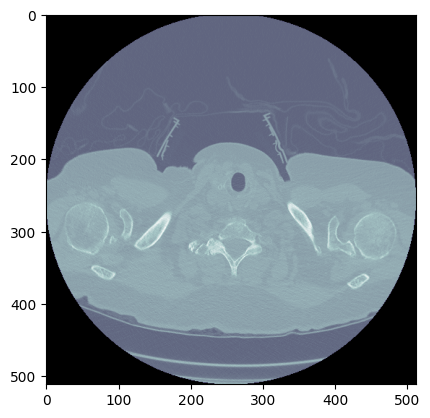

In [ ]:
import matplotlib.pyplot as plt
import pydicom
from pydicom.data import get_testdata_files

print(__doc__)

dataset = pydicom.dcmread('/Users/anurag/Downloads/CSC821 Files/manifest-1608266677008/MIDRC-RICORD-1A/MIDRC-RICORD-1A-419639-000082/08-02-2002-NA-CT CHEST WITHOUT CONTRAST-04614/3.000000-0.625mm bone alg-26970/1-001.dcm')


# Just viewing the details about the images.
pat_name = dataset.PatientName
display_name = pat_name.family_name + ", " + pat_name.given_name
print("Patient's name...:", display_name)
print("Patient id.......:", dataset.PatientID)
print("Modality.........:", dataset.Modality)
print("Study Date.......:", dataset.StudyDate)

if 'PixelData' in dataset:
    rows = int(dataset.Rows)
    cols = int(dataset.Columns)
    print("Image size.......: {rows:d} x {cols:d}, {size:d} bytes".format(
        rows=rows, cols=cols, size=len(dataset.PixelData)))
    if 'PixelSpacing' in dataset:
        print("Pixel spacing....:", dataset.PixelSpacing)

print("Slice location...:", dataset.get('SliceLocation', "(missing)"))

plt.imshow(dataset.pixel_array, cmap=plt.cm.bone)
plt.show()

## Method: looking at the volume

A VTK-based viewer that loads a whole series into a 3D volume and a folder viewer for scrolling through slices. These were debugging tools, not results: I needed to see the volume before trusting any mask.


In [ ]:
import os
import pydicom
import numpy as np
from vtkmodules.vtkCommonDataModel import vtkImageData
from vtkmodules.util import numpy_support
from vtkmodules.vtkCommonCore import VTK_FLOAT

def process_dicom_file(file_path):
    try:
        ds = pydicom.dcmread(file_path)
        print(f"Reading DICOM file: {file_path}")
        print(ds)
    except Exception as e:
        print(f"Error reading DICOM file {file_path}: {e}")
        return None

    pixel_array = ds.pixel_array

    # Check if the array is 2D or 3D
    if pixel_array.ndim == 2:  # For 2D images, add the depth as 1
        dimensions = (pixel_array.shape[0], pixel_array.shape[1], 1)
    else:
        dimensions = pixel_array.shape

    # Convert the NumPy array into VTK image data
    vtk_data = numpy_support.numpy_to_vtk(num_array=np.ravel(pixel_array), deep=True, array_type=VTK_FLOAT)
    image_data = vtkImageData()
    image_data.SetDimensions(dimensions)
    image_data.GetPointData().SetScalars(vtk_data)

    print(f"VTK Image Data Dimensions: {image_data.GetDimensions()}")
    return image_data

def process_dicom_folder(folder_path):
    for root, _, files in os.walk(folder_path):
        for file in files:
            if file.endswith(".dcm"):
                file_path = os.path.join(root, file)
                process_dicom_file(file_path)

if __name__ == "__main__":
    folder = "/Users/anurag/Downloads/CSC821 Files/manifest-1608266677008/MIDRC-RICORD-1A/MIDRC-RICORD-1A-419639-000082/08-02-2002-NA-CT CHEST WITHOUT CONTRAST-04614/3.000000-0.625mm bone alg-26970"  # Replace with the folder you want to process
    process_dicom_folder(folder)


In [ ]:
VTK_Image_Viewer.vtk_image_show_folder('/Users/anurag/Downloads/CSC821 Files/manifest-1608266677008/MIDRC-RICORD-1A/MIDRC-RICORD-1A-419639-000082/08-02-2002-NA-CT CHEST WITHOUT CONTRAST-04614/3.000000-0.625mm bone alg-26970')

## Method: the segmentation class

`COVIDLungSegmentation` reads a series into an ITK image, finds the lungs, finds the infection band, and quantifies the result. This is the version the experiments below use: IsoData thresholding directly on the HU values, connected-components to drop the background, and a median filter to clean up.

The earlier draft did more: it rescaled to 8-bit, ran adaptive histogram equalization, and used H-minima plus a marker-based morphological watershed. I simplified it away. The simplification then failed on real data (see below), and the final pipeline went back to thresholding with hole filling, a distance map, and watershed, which is what FINAL_PRESENTATION.ipynb uses.


In [ ]:
import itk.itkMorphologicalWatershedFromMarkersImageFilterPython

class COVIDLungSegmentation:
    
    def __init__(self, dicom_directory):

        self.dicom_directory = dicom_directory
        
        # Specific HU ranges for COVID-19 lung involvement
        self.lower_threshold = -700  # Lung air/ground-glass opacity lower bound
        self.upper_threshold = -200  # Consolidation upper bound
        
        # Initialize ITK image types
        self.PixelType = itk.ctype("short") 
        self.Dimension = 3
        self.ImageType = itk.Image[self.PixelType, self.Dimension]
        
        # Set up DICOM series reader
        self.setup_dicom_reader()
    
    def setup_dicom_reader(self):
        # Create DICOM name generator
        self.names_generator = itk.GDCMSeriesFileNames.New()
        self.names_generator.SetUseSeriesDetails(True)
        self.names_generator.AddSeriesRestriction("0008|0021")
        self.names_generator.SetGlobalWarningDisplay(False)
        self.names_generator.SetDirectory(self.dicom_directory)
        
        # Get series UIDs
        self.series_uids = self.names_generator.GetSeriesUIDs()
        
        if not self.series_uids:
            raise ValueError(f"No DICOM series found in {self.dicom_directory}")
        
        # Get filenames for the first series
        self.series_identifier = self.series_uids[0]
        self.filenames = self.names_generator.GetFileNames(self.series_identifier)
        
        # Set up image reader
        self.image_reader = itk.ImageSeriesReader[self.ImageType].New()
        self.dicom_io = itk.GDCMImageIO.New()
        self.image_reader.SetImageIO(self.dicom_io)
        self.image_reader.SetFileNames(self.filenames)
        self.image_reader.ForceOrthogonalDirectionOff()
    
    def read_dicom_series(self):
        try:
            self.image_reader.Update()
            return self.image_reader.GetOutput()
        except Exception as e:
            print(f"Error reading DICOM series: {e}")
            return None
    
    def segment_covid_lungs(self,output_directory=None,lower_threshold=None,upper_threshold=None):
        # Use custom thresholds if provided
        lt = lower_threshold if lower_threshold is not None else self.lower_threshold
        ut = upper_threshold if upper_threshold is not None else self.upper_threshold
        
        # Prepare output directory
        if output_directory is None:
            output_directory = os.path.join(self.dicom_directory, 'covid_segmentation')
        os.makedirs(output_directory, exist_ok=True)
        
        # Read the image series
        input_image = self.read_dicom_series()
        if input_image is None:
            return None
            
        # Convert to float for processing
        FloatImageType = itk.Image[itk.F, self.Dimension]
        castFilter = itk.CastImageFilter[self.ImageType, FloatImageType].New()
        castFilter.SetInput(input_image)
        
        # Threshold segmentation
        thresholdFilter = itk.BinaryThresholdImageFilter[FloatImageType, FloatImageType].New()
        thresholdFilter.SetInput(castFilter.GetOutput())
        thresholdFilter.SetLowerThreshold(lt)
        thresholdFilter.SetUpperThreshold(ut)
        thresholdFilter.SetInsideValue(1)
        thresholdFilter.SetOutsideValue(0)
        
        # Morphological operations to clean up the segmentation
        kernel = itk.FlatStructuringElement[self.Dimension].Ball(2)
        
        # median filter to remove small noise salt and pepper
        medianFilter = itk.MedianImageFilter[FloatImageType, FloatImageType].New()
        medianFilter.SetInput(thresholdFilter.GetOutput())
        medianFilter.SetRadius(2)
        medianFilter.Update()
        
        # Convert back to binary image
        BinaryImageType = itk.Image[itk.UC, self.Dimension]
        binaryCastFilter = itk.CastImageFilter[FloatImageType, BinaryImageType].New()
        binaryCastFilter.SetInput(medianFilter.GetOutput())
        binaryCastFilter.Update()
        
        if output_directory:
            writer = itk.ImageFileWriter[BinaryImageType].New()
            writer.SetFileName(os.path.join(output_directory, "covid_segmentation.nii.gz"))
            writer.SetInput(binaryCastFilter.GetOutput())
            writer.Update()
        
        print("Starting interactive viewer (use up/down arrow keys to navigate slices)...")
        view_nifti_slices(os.path.join(output_directory, "covid_segmentation.nii.gz"))
        
        return input_image,binaryCastFilter.GetOutput()

    def segment_lungs(self,input_image,output_directory=None):
        
        if output_directory is None:
            output_directory = os.path.join(self.dicom_directory, 'lung')
        os.makedirs(output_directory, exist_ok=True)
                
        # print(itk.size(input_image))  # Check the dimensions of the original image
        # print(itk.GetArrayViewFromImage(input_image).shape)  # Validate dimensions
        # image_array = itk.GetArrayViewFromImage(input_image)
        # plt.hist(image_array.flatten(), bins=256, range=(-2000, 2000))
        # plt.show()
        # # Add this before segmentation to understand your image's intensity range
        # image_array = itk.GetArrayFromImage(input_image)
        # print("Image HU Range:")
        # print(f"Minimum: {image_array.min()}")
        # print(f"Maximum: {image_array.max()}")
        # print(f"Mean: {image_array.mean()}")
        
        if input_image is None:
            print('returning none')
            return None  

        # Convert to float for initial processing
        FloatImageType = itk.Image[itk.F, self.Dimension]
        BinaryImageType = itk.Image[itk.UC, self.Dimension]
        ShortImageType = itk.Image[itk.SS, self.Dimension]
        
        
        castFilter = itk.CastImageFilter[self.ImageType, FloatImageType].New()
        castFilter.SetInput(input_image)
        castFilter.Update()

        isodataFilter = itk.IsoDataThresholdImageFilter[FloatImageType, BinaryImageType].New()
        isodataFilter.SetInput(castFilter.GetOutput())
        isodataFilter.Update()
        threshold_value = isodataFilter.GetThreshold()
        print(f"IsoData Threshold: {threshold_value}")   
        
        connected_filter = itk.ConnectedComponentImageFilter[BinaryImageType, itk.Image[itk.SS, self.Dimension]].New()  # Use appropriate types
        connected_filter.SetInput(isodataFilter.GetOutput())
        connected_filter.Update()
        
    
        connected_components = connected_filter.GetOutput() 
        connected_np = itk.GetArrayFromImage(connected_components)
        background_labels = set()
        for d in range(self.Dimension):  # Iterate through each dimension (2D or 3D)
            for i in [0, -1]:  # Check first and last slices/rows/cols
                slice_labels = np.unique(connected_np.take(i, axis=d))
                background_labels.update(slice_labels)


        background_labels.discard(0)
        
        background_mask = np.isin(connected_np, list(background_labels))
        output_np = np.where(background_mask, 0, itk.GetArrayFromImage(isodataFilter.GetOutput())) 
        output_image = itk.GetImageFromArray(output_np.astype(np.uint8)) # Or appropriate output type
        output_image.CopyInformation(isodataFilter.GetOutput())

        medianFilter = itk.MedianImageFilter[BinaryImageType, BinaryImageType].New()
        medianFilter.SetInput(output_image) 
        medianFilter.SetRadius(1)
        medianFilter.Update()

        if output_directory:
            writer = itk.ImageFileWriter[BinaryImageType].New()
            writer.SetFileName(os.path.join(output_directory, "lungs.nii.gz"))
            writer.SetInput(medianFilter.GetOutput())
            writer.Update()

        print("Segmentation complete.  Output written to:", os.path.join(output_directory, "lungs.nii.gz")) # More informative message

        view_nifti_slices(os.path.join(output_directory, "lungs.nii.gz"))

        return medianFilter.GetOutput()

    def quantify_infection(self,lung_mask,segmentation_mask):
        # Convert mask to numpy for analysis
        mask_array = itk.GetArrayFromImage(segmentation_mask)
        lung_array= itk.GetArrayFromImage(lung_mask)
        # Calculate infection metrics
        total_voxels = np.sum(lung_array > 0)
        infected_voxels = np.sum(mask_array > 0)
        infection_percentage = (infected_voxels / total_voxels) * 100
        
        return {
            'total_voxels': total_voxels,
            'infected_voxels': infected_voxels,
            'infection_percentage': infection_percentage
        }
        


Helpers for viewing NIfTI slices, one slice at a time or interactively.

In [ ]:

import nibabel as nib
def view_nifti_slices(nifti_path, slice_indices=None, cmap='gray'):
    # Load the NIfTI file
    img = nib.load(nifti_path)
    data = img.get_fdata()
    
    # Get dimensions
    x, y, z = data.shape
    
    # If no slice indices provided, take middle slices
    if slice_indices is None:
        slice_indices = [x//2, y//2, z//2]
    
    # Create a figure with three subplots (one for each orientation)
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
    
    # Sagittal view (YZ plane)
    ax1.imshow(np.rot90(data[slice_indices[0], :, :]), cmap=cmap)
    ax1.set_title(f'Sagittal Slice {slice_indices[0]}')
    
    # Coronal view (XZ plane)
    ax2.imshow(np.rot90(data[:, slice_indices[1], :]), cmap=cmap)
    ax2.set_title(f'Coronal Slice {slice_indices[1]}')
    
    # Axial view (XY plane)
    ax3.imshow(np.rot90(data[:, :, slice_indices[2]]), cmap=cmap)
    ax3.set_title(f'Axial Slice {slice_indices[2]}')
    
    plt.tight_layout()
    plt.show()

def view_nifti_interactive(nifti_path):

    img = nib.load(nifti_path)
    data = img.get_fdata()
    
    class IndexTracker:
        def __init__(self, ax, X):
            self.ax = ax
            self.X = X
            self.slices = X.shape[2]
            self.ind = self.slices//2
            
            self.im = ax.imshow(np.rot90(self.X[:, :, self.ind]), cmap='gray')
            self.update()
    
        def onscroll(self, event):
            if event.key == 'up':
                self.ind = (self.ind + 1) % self.slices
            elif event.key == 'down':
                self.ind = (self.ind - 1) % self.slices
            self.update()
    
        def update(self):
            self.im.set_data(np.rot90(self.X[:, :, self.ind]))
            self.ax.set_title(f'Slice {self.ind}/{self.slices}')
            self.im.axes.figure.canvas.draw()
    
    fig, ax = plt.subplots()
    tracker = IndexTracker(ax, data)
    fig.canvas.mpl_connect('key_press_event', tracker.onscroll)
    plt.show()

## Results: running it on a volume

Subject MIDRC-RICORD-1A-660042-000124. The volume is 512 x 512 x 210, HU range -1024 to 2141, mean -404.7, median -136. The IsoData threshold on this volume came out at -436.7 HU, and the lung mask below is what that threshold plus the cleanup steps produce.


itkSize3 ([512, 512, 210])
(210, 512, 512)
Image HU Range:
Minimum: -1024
Maximum: 2141
Mean: -404.6724231175014
Median: -136


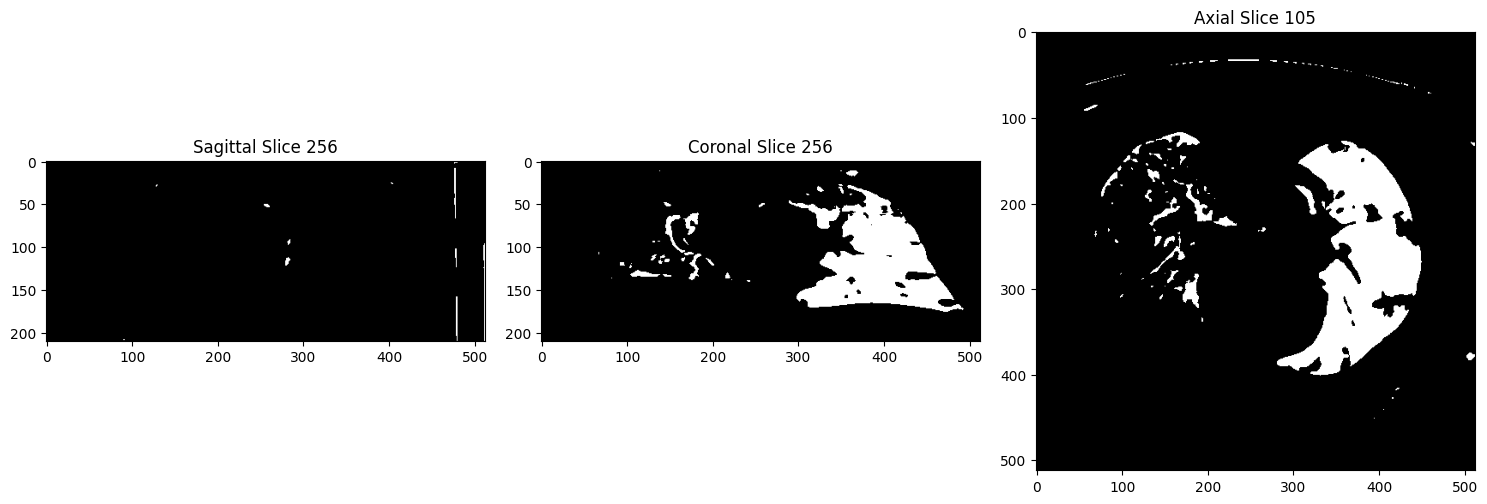

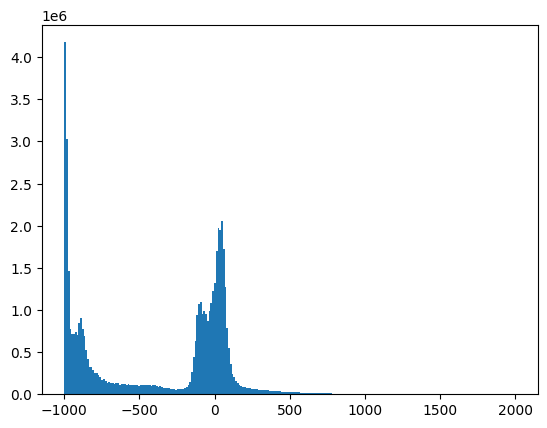

In [ ]:
dicom_dir = '/Users/anurag/Downloads/CSC821 Files/manifest-1608266677008/MIDRC-RICORD-1A/MIDRC-RICORD-1A-660042-000124/02-18-2008-NA-NA-29997/4.000000-NA-29998'
try:
    segmenter = COVIDLungSegmentation(dicom_dir)
    print("Performing segmentation...")
    input_volume,lung_mask= segmenter.segment_covid_lungs(dicom_dir)
    print(itk.size(input_volume))  # Check the dimensions of the original image
    print(itk.GetArrayViewFromImage(input_volume).shape)  # Validate dimensions
    image_array = itk.GetArrayViewFromImage(input_volume)
    plt.hist(image_array.flatten(), bins=256, range=(-1000, 2000))
    plt.show()
    
    image_array = itk.GetArrayFromImage(input_volume)
    print("Image HU Range:")
    print(f"Minimum: {image_array.min()}")
    print(f"Maximum: {image_array.max()}")
    print(f"Mean: {image_array.mean()}")
    print(int(np.median(image_array)))
    print(max(int(np.median(image_array)),int(image_array.mean())))
except Exception as e:
    print(f"An error occurred: {e}")

Segmenting the lungs from the loaded volume with the class above.

IsoData Threshold: -436.72119140625
Segmentation complete.


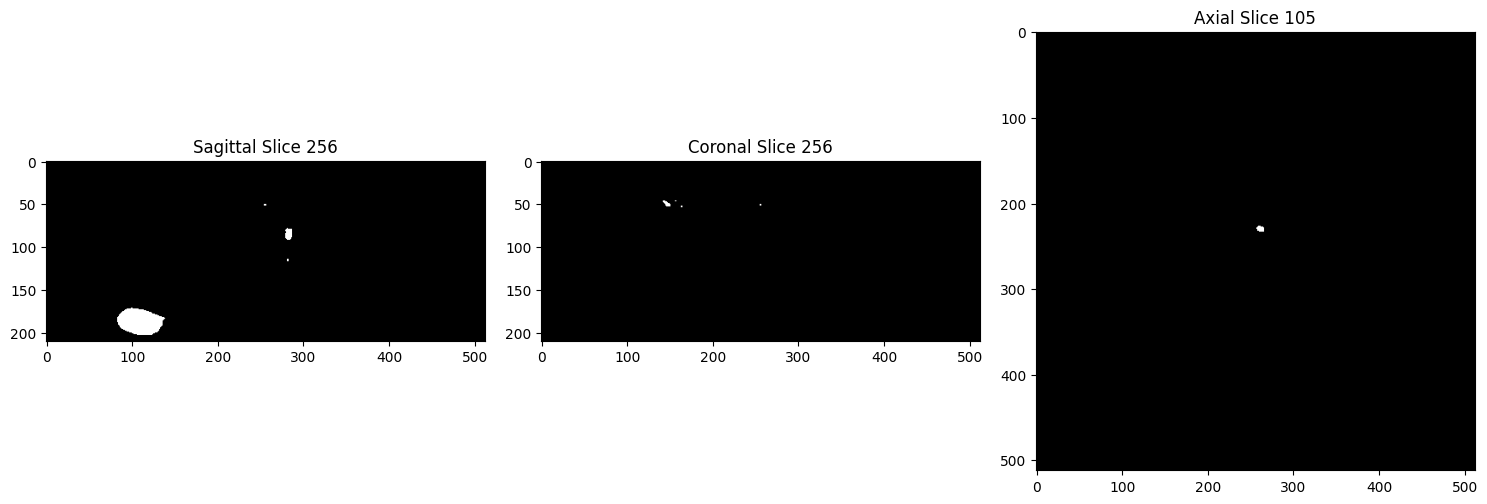

In [ ]:
lung = segmenter.segment_lungs(input_volume)

## What did not work

The connected-components version of `segment_lungs` blew up on a noisier series from subject MIDRC-RICORD-1A-660042-000107. ITK's ConnectedComponentImageFilter caps out at 255 labels and the mask had 883,236 separate objects, so the filter errored and the lung mask never got built. That is a real limitation of this approach on raw threshold output: without markers or size filtering first, connected components cannot handle CT noise. The shipped pipeline avoids it with the watershed route instead. A second run on another series was interrupted once the pattern was clear, so it is not shown.


In [ ]:

def main():
    dicom_dir = '/Users/anurag/Downloads/CSC821 Files/manifest-1608266677008/MIDRC-RICORD-1A/MIDRC-RICORD-1A-660042-000107/11-20-2008-NA-NA-25678/4.000000-NA-25679'
    try:
        segmenter = COVIDLungSegmentation(dicom_dir)
        print("Performing segmentation...")
        input_volume,lung_mask= segmenter.segment_covid_lungs(dicom_dir)
        lung = segmenter.segment_lungs(input_volume)
    except Exception as e:
        print(f"An error occurred: {e}")
    lung_array= itk.GetArrayFromImage(lung)

    total_voxels= np.sum(lung_array>0)
    print(total_voxels)
if __name__ == "__main__":
    main()

Performing segmentation...


One-line viewers for a finished volume, kept for reference.

In [ ]:
VTK_Image_Viewer.vtk_image_view(segmented_volume)

In [ ]:
view(segmented_volume, gradient_opacity=0.5)

## Takeaway

This notebook is the debugging trail behind the final pipeline. Reading DICOMs, sorting by slice position, and viewing volumes all worked. Lung segmentation took two tries: the marker-watershed draft was fragile, and the connected-components rewrite overflowed ITK's 255-label limit on noisy masks (883,236 objects). The approach that shipped is in FINAL_PRESENTATION.ipynb and segmentation.py: IsoData thresholding on HU values, hole filling, distance-map watershed, and median filtering. Nothing here is a clinical result; it is the engineering that the results stand on.
